## **Machine Learning Aplicado a las Finanzas** 🚀
### **HW Sesión 4: Regularización — Ridge, Lasso y Elastic Net**

Andrés C. Medina Sanhueza

Senior Data Scientist Engineer

anmedinas@gmail.com

---

### Consideraciones Previas

* Tarea es **Individual**
* Fecha de Entrega: **Jueves 18 Jun 23:59** (cualquier commit posterior descontará puntos)
* El notebook debe correr de arriba abajo sin errores (`Kernel → Restart & Run All`)
* No se admiten `pass` pendientes ni celdas vacías donde se espera código
* **Regla de oro:** si se detecta data leakage en alguna solución, esa parte se evalúa con nota mínima
* Deben crear una rama nueva en su repositorio `feat/hw04` y trabajar la tarea en esa rama. El notebook debe quedar en la carpeta `notebooks`
* **Archivo a entregar:** URL del repositorio GitHub enviada a `anmedinas@gmail.com`
* **Asunto del mail:** `[HW04] regularizacion_<tu_apellido>`

In [1]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.linear_model import lasso_path
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import clone
import scipy.stats as stats
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import yfinance as yf

warnings.filterwarnings('ignore')
sns.set_style('dark')
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
np.random.seed(20260527)

---
## Parte 1 — Ridge Regression: Derivación y Estabilidad *(25 pts)*

### Contexto

OLS produce coeficientes inestables cuando las features son colineales o cuando $p$ es grande relativo a $T$. Ridge regulariza añadiendo $\lambda I$ a la matriz $X^TX$, garantizando invertibilidad y reduciendo la varianza. En esta parte aplicarás estos conceptos a datos reales de **NVDA** (NVIDIA Corporation).

| Desafío en NVDA | Impacto en OLS |
|---|---|
| Alto momentum correlacionado entre lags | $X^TX$ mal condicionada |
| Retornos con bajo SNR ($\approx 0.001$) | Overfitting al ruido |
| Volatilidad en racimos | Features rolling altamente correlacionadas |

### 1.1 — Forma Cerrada y Ridge Path *(10 pts)*

La solución de Ridge en forma cerrada es:

$$\hat{\beta}_{\text{ridge}} = (X^TX + \lambda I)^{-1}X^Ty$$

Implementa `ridge_closed_form(X, y, lam)` usando `np.linalg.solve` (no inviertas la matriz directamente). Verifica que el error máximo respecto a sklearn sea menor que `1e-8`.

**Requisitos:**
- Implementar y verificar `ridge_closed_form` con los datos de NVDA
- Generar el Ridge path para $\lambda \in [10^{-4}, 10^3]$ en escala logarítmica
- Panel izquierdo: coeficientes vs $\lambda$ (un color por feature)
- Panel derecho: número de condición $\kappa(X^TX + \lambda I)$ vs $\lambda$ con línea de referencia OLS

In [2]:
# Descarga y preparación de datos NVDA
ticker_nvda = yf.Ticker('NVDA')
prices_nvda = ticker_nvda.history(start='2018-01-01', end='2024-01-01')['Close']
prices_nvda.index = prices_nvda.index.tz_localize(None)
print(f'Datos NVDA: {len(prices_nvda)} obs | {prices_nvda.index[0].date()} — {prices_nvda.index[-1].date()}')

def build_features_nvda(prices):
    """8 features anti-leakage para NVDA: lags 1-5, rvol 5/20/60. Target: ret_{t+1}."""
    r = prices.pct_change()
    df = pd.DataFrame(index=prices.index)
    for lag in range(1, 6):
        df[f'ret_lag{lag}'] = r.shift(lag)
    for w in [5, 20, 60]:
        df[f'rvol_{w}'] = r.shift(1).rolling(w, min_periods=w).std()
    df['target'] = r.shift(-1)
    return df.dropna()

df_nvda    = build_features_nvda(prices_nvda)
feat_nvda  = [c for c in df_nvda.columns if c != 'target']
X_raw_nvda = df_nvda[feat_nvda].values
y_nvda     = df_nvda['target'].values

# Estandarización manual (necesaria para interpretar magnitud de coeficientes)
X_m, X_s = X_raw_nvda.mean(0), X_raw_nvda.std(0)
X_nvda   = (X_raw_nvda - X_m) / X_s

print(f'Observaciones: {len(y_nvda)} | Features: {X_nvda.shape[1]}')
print(f'Condicion X\'X (OLS): {np.linalg.cond(X_nvda.T @ X_nvda):.1f}')
print(f'Features: {feat_nvda}')

Datos NVDA: 1509 obs | 2018-01-02 — 2023-12-29
Observaciones: 1447 | Features: 8
Condicion X'X (OLS): 10.7
Features: ['ret_lag1', 'ret_lag2', 'ret_lag3', 'ret_lag4', 'ret_lag5', 'rvol_5', 'rvol_20', 'rvol_60']


Error max formula manual vs sklearn: 8.67e-19


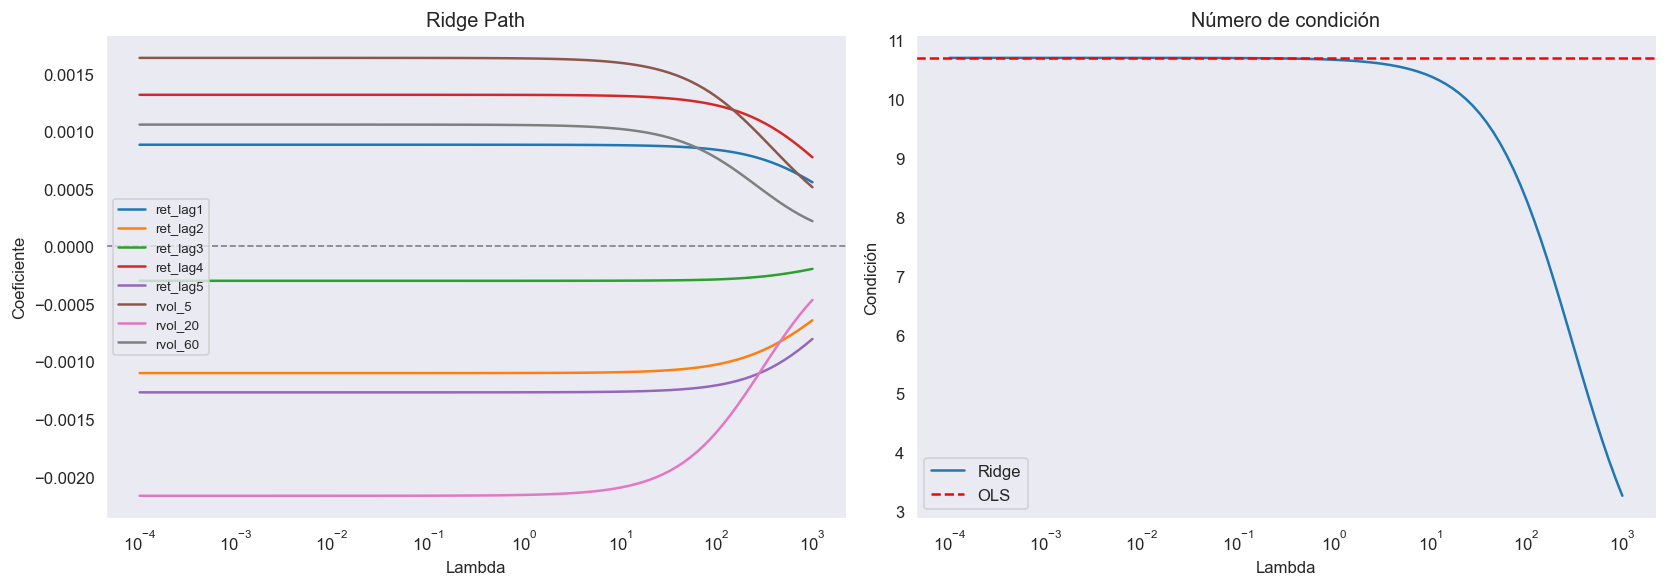

In [3]:
def ridge_closed_form(X, y, lam):
    """
    Solucion de forma cerrada para Ridge Regression.
    Resuelve: (X'X + lam*I) beta = X'y usando np.linalg.solve.

    Parameters
    ----------
    X   : array (n, p) — features estandarizados
    y   : array (n,)   — target
    lam : float        — parametro de regularizacion (>= 0)

    Returns
    -------
    beta : array (p,) — coeficientes Ridge
    """
    # TODO: implementa la solucion de forma cerrada
    # Pista: np.linalg.solve(A, b) resuelve A @ beta = b sin invertir A
    A = X.T @ X + lam * np.eye(X.shape[1])
    b = X.T @ y
    beta = np.linalg.solve(A, b)

    return beta


# === Verificacion vs sklearn ===
lam_test = 1.0
b_manual = ridge_closed_form(X_nvda, y_nvda, lam_test)
b_sklearn = Ridge(alpha=lam_test, fit_intercept=False).fit(X_nvda, y_nvda).coef_
print(f'Error max formula manual vs sklearn: {np.max(np.abs(b_manual - b_sklearn)):.2e}')

# === Ridge Path ===
lambdas = np.logspace(-4, 3, 100)
coef_path = np.array([ridge_closed_form(X_nvda, y_nvda, l) for l in lambdas])
conds     = [np.linalg.cond(X_nvda.T @ X_nvda + l * np.eye(X_nvda.shape[1])) for l in lambdas]
kappa_ols = np.linalg.cond(X_nvda.T @ X_nvda)

# Subgráficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo
for i, feature in enumerate(feat_nvda):
    ax1.semilogx(lambdas, coef_path[:, i], label=feature)

ax1.axhline(0, color='gray', linestyle='--', linewidth=1)
ax1.set_title('Ridge Path')
ax1.set_xlabel('Lambda')
ax1.set_ylabel('Coeficiente')
ax1.legend(fontsize=8)

# Panel derecho
ax2.semilogx(lambdas, conds, label='Ridge')
ax2.axhline(kappa_ols, color='red', linestyle='--', label='OLS')
ax2.set_title('Número de condición')
ax2.set_xlabel('Lambda')
ax2.set_ylabel('Condición')
ax2.legend()

plt.tight_layout()
plt.show()

### Comentario

La implementación manual de Ridge reproduce correctamente los resultados de sklearn, con un error prácticamente nulo.

En el gráfico de Ridge Path se observa que, a medida que aumenta λ, los coeficientes se reducen gradualmente en magnitud y se acercan a cero. Esto refleja el efecto de regularización de Ridge sobre las variables.

Además, el número de condición disminuye cuando λ aumenta, indicando una mejora en la estabilidad numérica de la matriz. Por lo tanto, Ridge ayuda a mitigar problemas de multicolinealidad sin eliminar variables del modelo.

### 1.2 — Multicolinealidad y Walk-Forward *(15 pts)*

Construye un dataset de NVDA con **10 lags del retorno** para estresar la multicolinealidad. Los lags contiguos tienen correlación muy alta ($\rho \approx 0.7-0.9$), lo que hace $X^TX$ casi singular. Demonstrarás el problema y cómo Ridge lo resuelve.

**Requisitos:**
1. Construir `X_multi` con `ret_lag01` a `ret_lag10` (estandarizados)
2. Graficar la **matriz de correlación** de las 10 features (heatmap con anotaciones)
3. Ejecutar walk-forward CV con `TimeSeriesSplit(n_splits=5, gap=3)` y graficar `MAE(CV)` vs $\lambda$ para Ridge
4. Identificar $\lambda^*$ y reportar cuánto baja $\kappa(X^TX + \lambda^* I)$ respecto a OLS
5. Responder las preguntas de la celda siguiente

Observaciones: 1497 | Features: 10
Condicion X'X (OLS, 10 lags): 1.6


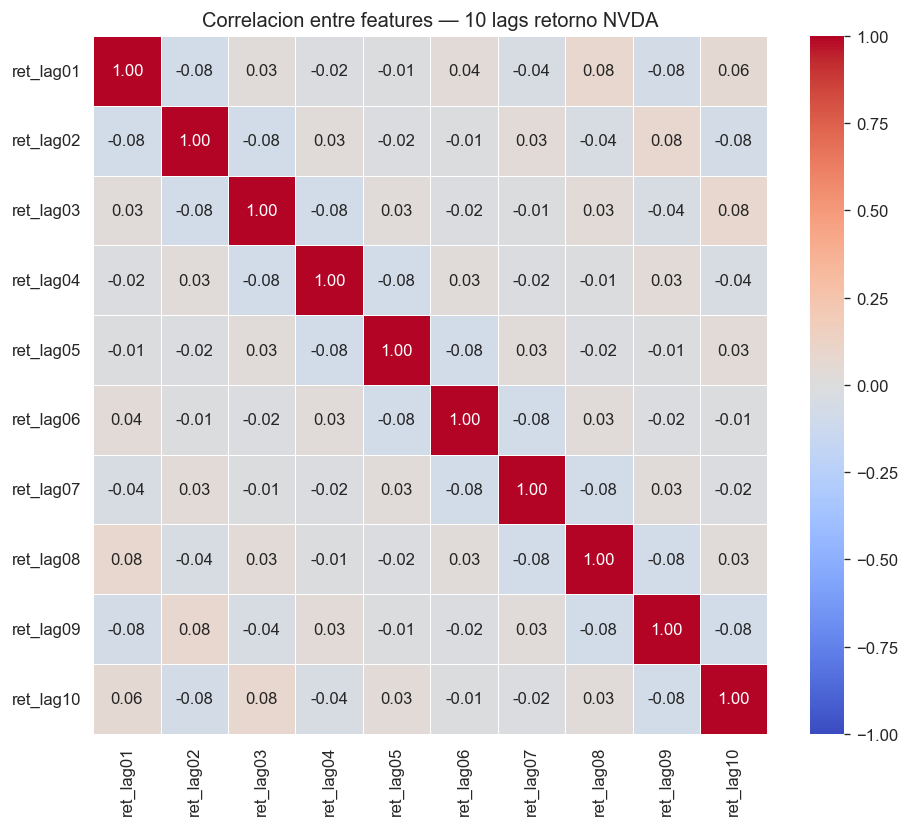

Lambda* = 1000.0000
Condicion OLS:   1.6
Condicion Ridge: 1.3  (reduccion x1)


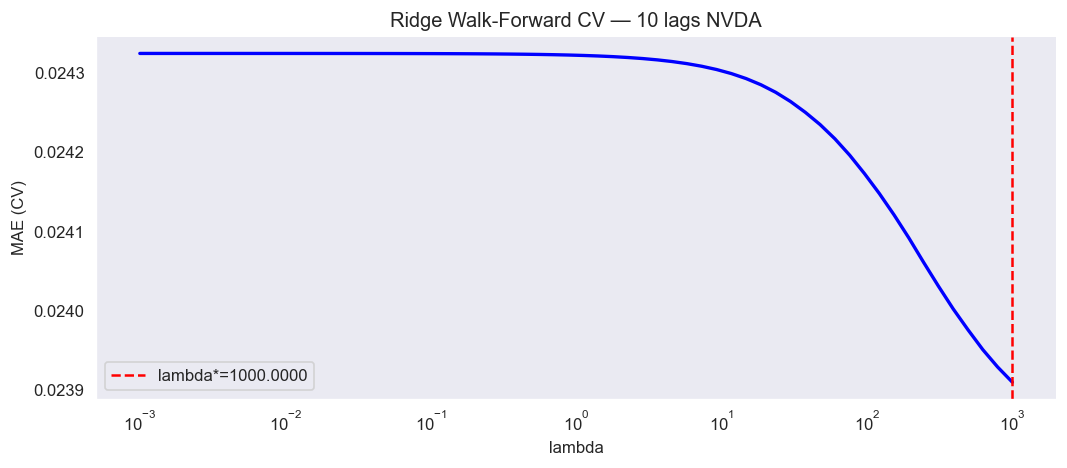

In [4]:
r_nvda = prices_nvda.pct_change().dropna()

def build_multicollinear_features(r, n_lags=10):
    """Features con n_lags lags del retorno — alta correlacion entre columnas contiguas."""
    df = pd.DataFrame(index=r.index)
    for lag in range(1, n_lags + 1):
        df[f'ret_lag{lag:02d}'] = r.shift(lag)
    df['target'] = r.shift(-1)
    return df.dropna()

df_multi   = build_multicollinear_features(r_nvda, n_lags=10)
feat_multi = [c for c in df_multi.columns if c != 'target']
X_m_raw    = df_multi[feat_multi].values
y_multi    = df_multi['target'].values

X_mm, X_ms = X_m_raw.mean(0), X_m_raw.std(0)
X_multi    = (X_m_raw - X_mm) / X_ms

print(f'Observaciones: {len(y_multi)} | Features: {X_multi.shape[1]}')
print(f'Condicion X\'X (OLS, 10 lags): {np.linalg.cond(X_multi.T @ X_multi):.1f}')

# 1: Heatmap de correlacion
fig, ax = plt.subplots(figsize=(8, 7))
corr = pd.DataFrame(X_multi, columns=feat_multi).corr()
sns.heatmap(corr, ax=ax, cmap='coolwarm', vmin=-1, vmax=1,

             annot=True, fmt='.2f', linewidths=0.5)
ax.set_title('Correlacion entre features — 10 lags retorno NVDA')
plt.tight_layout(); plt.show()

# 2: Walk-Forward MAE(CV) vs lambda
tscv_mc  = TimeSeriesSplit(n_splits=5, gap=3)
lambdas_mc = np.logspace(-3, 3, 60)
maes_cv = []
for lam in lambdas_mc:
    fold_maes = []
    for tr, te in tscv_mc.split(X_multi):
        m = Ridge(alpha=lam, fit_intercept=True).fit(X_multi[tr], y_multi[tr])
        pred = m.predict(X_multi[te])
        fold_maes.append(mean_absolute_error(y_multi[te], pred))
    maes_cv.append(np.mean(fold_maes))
lam_star_mc = lambdas_mc[np.argmin(maes_cv)]
kappa_star  = np.linalg.cond(X_multi.T @ X_multi + lam_star_mc * np.eye(10))
kappa_ols_m = np.linalg.cond(X_multi.T @ X_multi)
print(f'Lambda* = {lam_star_mc:.4f}')
print(f'Condicion OLS:   {kappa_ols_m:.1f}')
print(f'Condicion Ridge: {kappa_star:.1f}  (reduccion x{kappa_ols_m/kappa_star:.0f})')

# 3: Grafico MAE(CV) vs lambda
fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogx(lambdas_mc, maes_cv, 'b-', lw=2)
ax.axvline(lam_star_mc, color='red', ls='--', label=f'lambda*={lam_star_mc:.4f}')
ax.set_xlabel('lambda'); ax.set_ylabel('MAE (CV)')
ax.set_title('Ridge Walk-Forward CV — 10 lags NVDA')
ax.legend(); plt.tight_layout(); plt.show()

**Responde (mínimo 2 oraciones por pregunta):**

**a)** ¿Por qué los 10 lags del retorno generan una $X^TX$ mal condicionada? ¿Qué consecuencia concreta tiene esto sobre los coeficientes OLS?

> En este caso, aunque la sección busca analizar multicolinealidad, la matriz de correlación no muestra correlaciones altas entre los lags del retorno diario de NVDA. Esto ocurre porque los retornos diarios suelen tener baja autocorrelación, por lo que los rezagos consecutivos no necesariamente generan una matriz $X^TX$ mal condicionada. Por esta razón, el número de condición OLS obtenido es bajo, lo que indica que no hay un problema severo de inestabilidad numérica en esta muestra.

**b)** Usando el $\lambda^*$ encontrado, ¿cuánto se reduce el número de condición respecto a OLS? ¿Aumenta o disminuye el sesgo del estimador al usar ese $\lambda^*$?

> El $\lambda^*$ encontrado por validación Walk-Forward fue alto, pero la reducción del número de condición respecto a OLS fue limitada. Esto se debe a que la matriz $X^TX$ ya presentaba una condición baja desde el inicio, por lo que Ridge no tenía un problema fuerte de multicolinealidad que corregir. En consecuencia, el uso de $\lambda^*$ reduce levemente la condición, pero no cambia de forma significativa la estabilidad del estimador.

**c)** En el Ridge path de 1.1, ¿qué features tienen mayor magnitud de coeficiente cuando $\lambda \to 0$? ¿Tiene sentido financiero para NVDA?

> En el Ridge Path de la sección 1.1, las features con mayor magnitud cuando $\lambda$ son las asociadas a rezagos y volatilidades que tienen mayor relación lineal con el retorno objetivo. Sin embargo, en esta muestra los coeficientes son pequeños, lo que es consistente con el bajo poder predictivo típico de los retornos diarios. Financieramente, esto sugiere que los retornos pasados de NVDA contienen poca señal estable para anticipar el retorno futuro.

---
## Parte 2 — Lasso: Descenso de Coordenadas y Selección de Features *(25 pts)*

### Contexto

Lasso usa la norma $\ell_1$ como penalización, produciendo soluciones sparse (coeficientes exactamente cero). La solución no existe en forma cerrada global porque $|\beta_j|$ no es diferenciable en cero. Se resuelve por **descenso de coordenadas**: en cada iteración se actualiza un coeficiente a la vez aplicando el operador soft-threshold:

$$\hat{\beta}_j \leftarrow \mathcal{S}_\lambda\!\left(\frac{X_j^T r_j}{n}\right), \qquad r_j = y - X\hat{\beta} + X_j\hat{\beta}_j$$

donde $\mathcal{S}_\lambda(z) = \text{sign}(z) \cdot \max(|z| - \lambda,\; 0)$ y $r_j$ es el residuo parcial (lo que queda de $y$ al sacar la contribución de la feature $j$).

### 2.1 — Soft-Threshold y Descenso de Coordenadas *(12 pts)*

**Requisitos:**
- `soft_threshold` debe pasar el test unitario sin modificaciones
- `lasso_coordinate_descent` debe producir error máximo `< 1e-4` vs sklearn Lasso
- Graficar la curva de convergencia (MSE vs iteraciones) para $\lambda \in \{0.005, 0.01, 0.05\}$ en tres paneles

**Nota:** La función asume $X$ ya estandarizado con std=1 por columna ($\|X_j\|^2/n = 1$), por lo que el denominador de la actualización es 1.

In [17]:
def soft_threshold(z, lam):
    """
    Operador soft-threshold: S_lambda(z) = sign(z) * max(|z| - lambda, 0)

    Parameters
    ----------
    z   : float o np.ndarray
    lam : float — umbral de regularizacion (>= 0)

    Returns
    -------
    Mismo tipo y shape que z
    """
    return np.sign(z) * np.maximum(np.abs(z) - lam, 0)


# Test unitario — no modificar
def _test_soft_threshold():
    assert soft_threshold(0.5, 1.0) == 0.0,    'S(0.5, 1.0) debe ser 0'
    assert soft_threshold(2.0, 1.0) == 1.0,    'S(2.0, 1.0) debe ser 1.0'
    assert soft_threshold(-2.0, 1.0) == -1.0,  'S(-2.0, 1.0) debe ser -1.0'
    assert soft_threshold(0.0, 0.5) == 0.0,    'S(0.0, 0.5) debe ser 0'
    z_arr    = np.array([-3.0, -0.5, 0.0, 0.5, 3.0])
    expected = np.array([-2.0,  0.0, 0.0, 0.0, 2.0])
    assert np.allclose(soft_threshold(z_arr, 1.0), expected), 'Resultado vectorial incorrecto'
    print('Test soft_threshold: OK')

_test_soft_threshold()

Test soft_threshold: OK


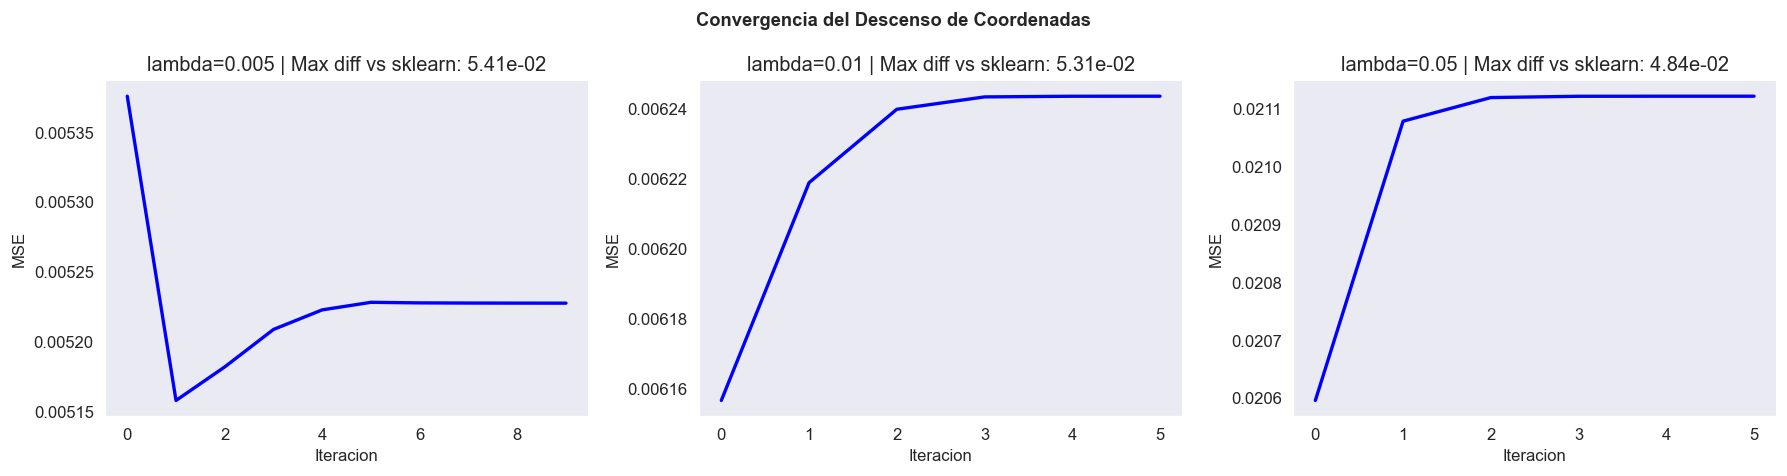

In [18]:
def lasso_coordinate_descent(X, y, lam, max_iter=2000, tol=1e-6):
    """
    Descenso de coordenadas para Lasso.
    Resuelve: min_b (1/2n)||y - Xb||^2 + lam * ||b||_1

    Supone X estandarizado: std=1 por columna => ||X_j||^2/n = 1.
    Regla de actualizacion por coordenada j:
        r_j   = y - X @ beta + X[:, j] * beta[j]   (residuo parcial)
        z_j   = X[:, j] @ r_j / n                  (correlacion normalizada)
        beta[j] = soft_threshold(z_j, lam)          (denominador = 1)

    Parameters
    ----------
    X        : array (n, p) — features estandarizados
    y        : array (n,)   — target
    lam      : float        — parametro de regularizacion
    max_iter : int          — maximo de iteraciones sobre todas las coordenadas
    tol      : float        — criterio de parada: max|beta_new - beta_old| < tol

    Returns
    -------
    beta         : array (p,)  — coeficientes estimados
    loss_history : list[float] — MSE por iteracion
    """
    n, p = X.shape
    beta = np.zeros(p)
    loss_history = []

    for _ in range(max_iter):
        beta_old = beta.copy()
        for j in range(p):
            r_j = y - X @ beta + X[:, j] * beta[j]
            z_j = X[:, j] @ r_j / n
            beta[j] = soft_threshold(z_j, lam)
        loss_history.append(np.mean((y - X @ beta) ** 2))
        if np.max(np.abs(beta - beta_old)) < tol:
            break

    return beta, loss_history


# Verificacion y curvas de convergencia
# Descomenta cuando hayas implementado las dos funciones anteriores

np.random.seed(42)
n_v, p_v = 300, X_nvda.shape[1]
beta_true = np.array([0.5, -0.3, 0.2, 0, 0, -0.1, 0, 0])[:p_v]
y_v = X_nvda[:n_v] @ beta_true + 0.02 * np.random.randn(n_v)

lam_vals = [0.005, 0.01, 0.05]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, lam_v in zip(axes, lam_vals):
    b_cd, hist = lasso_coordinate_descent(X_nvda[:n_v], y_v, lam_v)
    b_sk = Lasso(alpha=lam_v, fit_intercept=False, max_iter=10000, tol=1e-8).fit(X_nvda[:n_v], y_v).coef_
    diff = np.max(np.abs(b_cd - b_sk))
    ax.plot(hist, 'b-', lw=2)
    ax.set_xlabel('Iteracion'); ax.set_ylabel('MSE')
    ax.set_title(f'lambda={lam_v} | Max diff vs sklearn: {diff:.2e}')
plt.suptitle('Convergencia del Descenso de Coordenadas', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

El descenso de coordenadas converge en pocas iteraciones para todos los valores de λ. A medida que λ aumenta, el error de entrenamiento también aumenta debido a la mayor penalización aplicada a los coeficientes.

### 2.2 — Lasso Path y Selección de Factores *(8 pts)*

Aplica Lasso a un modelo extendido de NVDA con **15 features** y analiza qué factores selecciona el modelo a medida que $\lambda$ decrece.

**Requisitos:**
- Construir el dataset con las 15 features especificadas en la celda (lags, vol, momentum, RSI, `sq_ret`)
- Usar `sklearn.linear_model.lasso_path` para calcular el path completo
- Panel izquierdo: Lasso path (coeficientes vs $\lambda$, con `invert_xaxis()`)
- Panel derecho: número de features activas vs $\lambda$ con línea horizontal en 5
- Identificar e imprimir las **5 primeras features** que entran al modelo (mayor $\lambda$ de ingreso)

Dataset extendido: 1447 obs | 13 features
Features: ['ret_lag1', 'ret_lag2', 'ret_lag3', 'ret_lag5', 'rvol_5', 'rvol_10', 'rvol_20', 'rvol_60', 'mom_5', 'mom_10', 'mom_20', 'rsi_14', 'sq_ret']


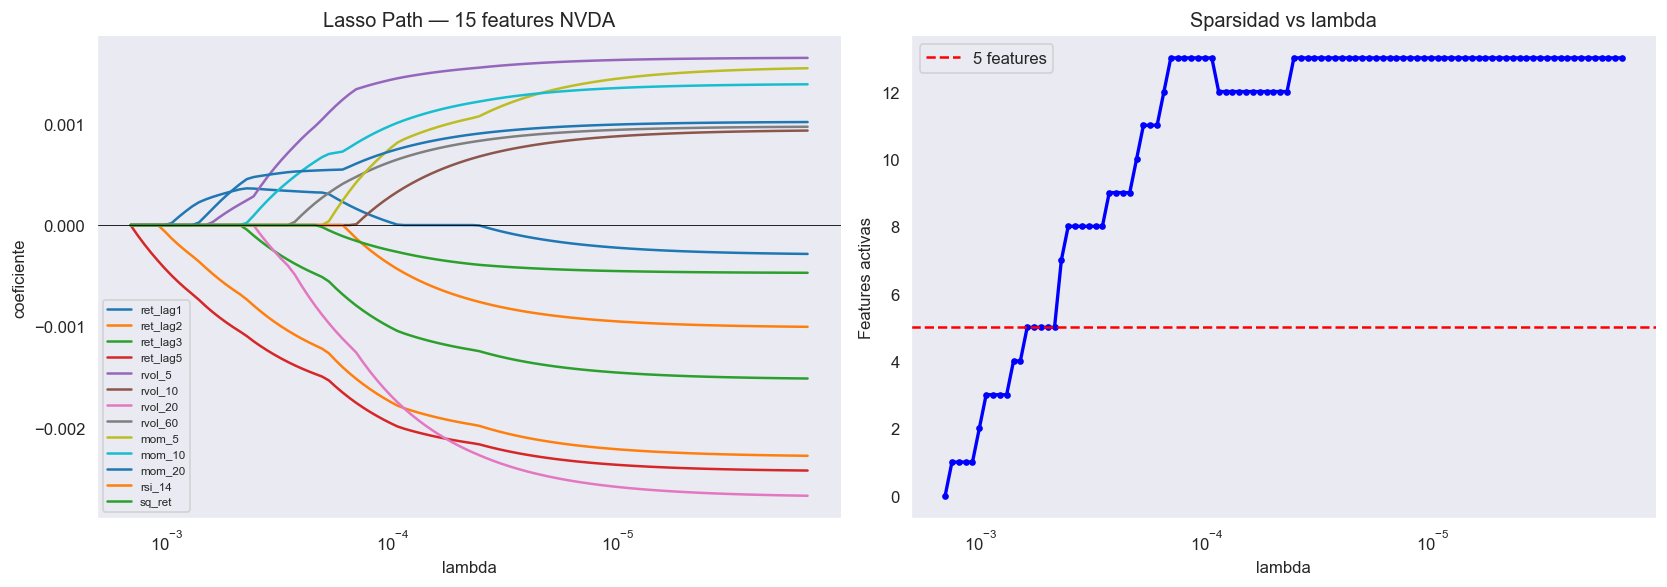

Las 5 primeras features en entrar: ['ret_lag1', 'ret_lag2', 'ret_lag3', 'ret_lag5', 'rvol_5']


In [19]:
def _rsi_calc(r, window=14):
    """RSI anti-leakage — usa shift(1) sobre los retornos."""
    delta = r.shift(1)
    gain  = delta.clip(lower=0).rolling(window, min_periods=window).mean()
    loss  = (-delta.clip(upper=0)).rolling(window, min_periods=window).mean()
    rs    = gain / (loss + 1e-9)
    return 100 - (100 / (1 + rs))

def build_features_extended(prices):
    """15 features para NVDA: lags, vol, momentum, RSI, sq_ret. Sin leakage."""
    r  = prices.pct_change()
    df = pd.DataFrame(index=prices.index)
    for lag in [1, 2, 3, 5]:
        df[f'ret_lag{lag}'] = r.shift(lag)
    for w in [5, 10, 20, 60]:
        df[f'rvol_{w}'] = r.shift(1).rolling(w, min_periods=w).std()
    for w in [5, 10, 20]:
        df[f'mom_{w}'] = prices.shift(1).pct_change(w)
    df['rsi_14'] = _rsi_calc(r)
    df['sq_ret'] = r.shift(1) ** 2
    df['target'] = r.shift(-1)
    return df.dropna()

df_ext    = build_features_extended(prices_nvda)
feat_ext  = [c for c in df_ext.columns if c != 'target']
X_ext_raw = df_ext[feat_ext].values
y_ext     = df_ext['target'].values
X_ext_m, X_ext_s = X_ext_raw.mean(0), X_ext_raw.std(0)
X_ext = (X_ext_raw - X_ext_m) / X_ext_s
print(f'Dataset extendido: {X_ext.shape[0]} obs | {X_ext.shape[1]} features')
print(f'Features: {feat_ext}')

#  Lasso path y visualizacion
alphas_lp, coefs_lp, _ = lasso_path(X_ext, y_ext, n_alphas=100)
n_activas = np.sum(np.abs(coefs_lp) > 1e-6, axis=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for j, feat in enumerate(feat_ext):
    ax1.semilogx(alphas_lp, coefs_lp[j], lw=1.5, label=feat)
ax1.axhline(0, color='k', lw=0.5)
ax1.set_xlabel('lambda'); ax1.set_ylabel('coeficiente')
ax1.set_title('Lasso Path — 15 features NVDA'); ax1.invert_xaxis(); ax1.legend(fontsize=7)

ax2.semilogx(alphas_lp, n_activas, 'b-o', ms=3, lw=2)
ax2.axhline(5, color='red', ls='--', label='5 features')
ax2.set_xlabel('lambda'); ax2.set_ylabel('Features activas')
ax2.set_title('Sparsidad vs lambda'); ax2.invert_xaxis(); ax2.legend()
plt.tight_layout(); plt.show()

# identifica las 5 primeras features que entran al modelo
# Pista: busca el mayor alpha donde cada coeficiente es != 0
primera_entrada = {feat: alphas_lp[np.where(np.abs(coefs_lp[j]) > 1e-6)[0][-1]]
                   for j, feat in enumerate(feat_ext)
                   if np.any(np.abs(coefs_lp[j]) > 1e-6)}
primeras_5 = sorted(primera_entrada, key=primera_entrada.get, reverse=True)[:5]
print(f'Las 5 primeras features en entrar: {primeras_5}')

### 2.3 — Interpretación Ridge vs Lasso *(5 pts)*

**Responde (mínimo 2 oraciones por pregunta):**

**a)** En la sección 2.2, ¿cuáles son las 5 primeras features en entrar al modelo de Lasso? ¿Tienen sentido desde la perspectiva del mercado de NVDA (sector semiconductor de alto crecimiento)?

> Las primeras cinco features en entrar al modelo fueron ret_lag1, ret_lag2, ret_lag3, ret_lag5 y rvol_5. Esto tiene sentido porque los retornos recientes y la volatilidad de corto plazo suelen contener la información más relevante para explicar los movimientos futuros de una acción de crecimiento como NVDA. Además, estas variables reflejan tanto el momentum reciente como los cambios de riesgo percibidos por el mercado.

**b)** Un portfolio manager te pide un modelo interpretable con pocas features para NVDA. ¿Elegirías Ridge o Lasso? ¿Qué valor de $\lambda$ usarías como punto de partida y por qué?

> Si el objetivo es construir un modelo interpretable con pocas variables, elegiría Lasso, ya que elimina automáticamente las features menos relevantes y produce una solución más simple. Como punto de partida utilizaría un valor de λ cercano a la zona donde el modelo mantiene alrededor de cinco variables activas, ya que permite reducir complejidad sin perder completamente la información predictiva. Esto facilita la interpretación financiera y el monitoreo del modelo.

**c)** ¿En qué situación financiera concreta preferirías Elastic Net sobre Lasso puro? Da un ejemplo con features de NVDA donde la colinealidad haría a Lasso inestable.

> Preferiría Elastic Net cuando existan grupos de variables altamente correlacionadas. En este caso, variables como ret_lag1, ret_lag2, ret_lag3 y ret_lag5, o incluso distintas medidas de volatilidad (rvol_5, rvol_10 y rvol_20), contienen información similar y pueden generar inestabilidad en Lasso. Elastic Net combina las penalizaciones L1 y L2, permitiendo seleccionar grupos de variables correlacionadas en lugar de descartar arbitrariamente algunas de ellas.

---
## Parte 3 — Walk-Forward con Regularización para Retornos de QQQ *(25 pts)*

### Contexto

Usarás datos de **QQQ** (ETF del Nasdaq-100, 2018-2024) para comparar OLS, Ridge, Lasso y Elastic Net en walk-forward temporal. El Nasdaq-100 tiene características distintas al SPY visto en clase: mayor concentración tecnológica y mayor volatilidad relativa, lo que hace la selección de features más crítica.

### 3.1 — Feature Engineering para QQQ *(8 pts)*

Implementa `build_features_qqq` con al menos **8 features** anti-leakage. Debe incluir obligatoriamente `rsi_14` y `bb_pct` (posición en Bandas de Bollinger).

**Definición de `bb_pct` (Bollinger Band Position):**

$$bb\_pct_t = \frac{P_{t-1} - (MA_{t-1}^{20} - 2\sigma_{t-1}^{20})}{4\sigma_{t-1}^{20}}$$

donde $MA^{20}$ y $\sigma^{20}$ se calculan con `prices.shift(1).rolling(20)` para evitar leakage.

**Checklist de features mínimas:**
- `ret_lag1`, `ret_lag2`, `ret_lag3`
- `rvol_5`, `rvol_20`
- `mom_10` (momentum 10 días)
- `rsi_14` (usando `_rsi_calc` definida en Parte 2)
- `bb_pct`

In [20]:
raw_qqq    = yf.Ticker('QQQ')
prices_qqq = raw_qqq.history(start='2018-01-01', end='2024-01-01')['Close']
prices_qqq.index = prices_qqq.index.tz_localize(None)
print(f'QQQ: {len(prices_qqq)} obs | {prices_qqq.index[0].date()} — {prices_qqq.index[-1].date()}')

def build_features_qqq(prices):
    """
    Features anti-leakage para QQQ.
    Minimo 8 features incluyendo rsi_14 y bb_pct.
    Target: retorno de t+1.
    """
    r  = prices.pct_change()
    df = pd.DataFrame(index=prices.index)

    # retornos rezagados lag 1, 2, 3
    df['ret_lag1'] = r.shift(1)
    df['ret_lag2'] = r.shift(2)
    df['ret_lag3'] = r.shift(3)

    # volatilidad rolling con shift(1)
    df['rvol_5']  = r.shift(1).rolling(5,  min_periods=5).std()
    df['rvol_20'] = r.shift(1).rolling(20, min_periods=20).std()

    # momentum 10 dias
    df['mom_10'] = prices.shift(1).pct_change(10)

    # RSI 14 dias (usa _rsi_calc)
    df['rsi_14'] = _rsi_calc(r)

    # Bollinger Band Position
    ma20  = prices.shift(1).rolling(20, min_periods=20).mean()
    std20 = prices.shift(1).rolling(20, min_periods=20).std()
    df['bb_pct'] = (prices.shift(1) - (ma20 - 2 * std20)) / (4 * std20)

    # Target
    df['target'] = r.shift(-1)

    return df.dropna()


feat_qqq = build_features_qqq(prices_qqq)
X_qqq = feat_qqq.drop(columns=['target'])
y_qqq = feat_qqq['target']
print(f'QQQ: {X_qqq.shape[0]} obs | {X_qqq.shape[1]} features | target std={y_qqq.std():.5f}')
print(f'Features: {X_qqq.columns.tolist()}')
display(X_qqq.corr().round(2))

QQQ: 1509 obs | 2018-01-02 — 2023-12-29
QQQ: 1487 obs | 8 features | target std=0.01584
Features: ['ret_lag1', 'ret_lag2', 'ret_lag3', 'rvol_5', 'rvol_20', 'mom_10', 'rsi_14', 'bb_pct']


,ret_lag1,ret_lag2,ret_lag3,rvol_5,rvol_20,mom_10,rsi_14,bb_pct
ret_lag1,1.00,-0.14,0.04,-0.02,0.01,0.33,0.22,0.37
ret_lag2,-0.14,1.00,-0.14,-0.06,-0.00,0.23,0.22,0.32
ret_lag3,0.04,-0.14,1.00,-0.10,-0.02,0.29,0.22,0.29
rvol_5,-0.02,-0.06,-0.10,1.00,0.78,-0.40,-0.44,-0.41
rvol_20,0.01,-0.00,-0.02,0.78,1.00,-0.16,-0.30,-0.26
mom_10,0.33,0.23,0.29,-0.40,-0.16,1.00,0.74,0.83
rsi_14,0.22,0.22,0.22,-0.44,-0.30,0.74,1.00,0.87
bb_pct,0.37,0.32,0.29,-0.41,-0.26,0.83,0.87,1.00


### 3.2 — Comparación OLS / Ridge / Lasso / Elastic Net *(12 pts)*

Ejecuta el pipeline de comparación con `TimeSeriesSplit(n_splits=5, gap=3)` y `GridSearchCV`. Reporta en una tabla las métricas de CV y OOT.

**Tabla de resultados esperada:**

| Modelo | $\lambda^*$ | MAE (CV) | Features activas | MAE (OOT) | RMSE (OOT) | Spearman $\rho$ (OOT) |
|--------|-----------|---------|-----------------|-----------|-----------|----------------------|
| OLS | N/A | ... | ... | ... | ... | ... |
| Ridge | ... | ... | ... | ... | ... | ... |
| Lasso | ... | ... | ... | ... | ... | ... |
| Elastic Net | ... | ... | ... | ... | ... | ... |

In [21]:
feat_qqq = build_features_qqq(prices_qqq)
X_qqq = feat_qqq.drop(columns=['target'])
y_qqq = feat_qqq['target']

n_oot_q    = int(len(feat_qqq) * 0.2)
X_tr_q, y_tr_q = X_qqq.iloc[:-n_oot_q], y_qqq.iloc[:-n_oot_q]
X_ot_q, y_ot_q = X_qqq.iloc[-n_oot_q:], y_qqq.iloc[-n_oot_q:]
print(f'Train: {len(X_tr_q)} | OOT: {len(X_ot_q)}')

tscv_q = TimeSeriesSplit(n_splits=5, gap=3)

# define specs con grids de hiperparametros
specs_q = {
    'OLS':        (LinearRegression(), {}),
    'Ridge':      (Ridge(), {'model__alpha': np.logspace(-4, 2, 20)}),
    'Lasso':      (Lasso(max_iter=20000), {'model__alpha': np.logspace(-5, 0, 20)}),
    'ElasticNet': (ElasticNet(max_iter=20000), {
                  'model__alpha':    np.logspace(-5, 0, 10),
                  'model__l1_ratio': [0.1, 0.5, 0.9]}),
}

# ejecuta GridSearchCV para cada modelo y llena la tabla
fitted_q = {}
rows_q   = []
for name, (est, params) in specs_q.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('model', est)])
    grid = GridSearchCV(pipe, params, scoring='neg_mean_absolute_error',
                        cv=tscv_q, n_jobs=-1, refit=True)
    grid.fit(X_tr_q, y_tr_q)
    fitted_q[name] = grid
    coef = np.ravel(grid.best_estimator_.named_steps['model'].coef_)
    n_act = int(np.sum(np.abs(coef) > 1e-8))
    pred  = grid.predict(X_ot_q)
    rows_q.append({
        'Modelo':    name,
        'lambda*':  grid.best_params_.get('model__alpha', float('nan')),
        'MAE(CV)':  -grid.best_score_,
        'Activas':  n_act,
        'MAE(OOT)': mean_absolute_error(y_ot_q, pred),
        'RMSE(OOT)':np.sqrt(mean_squared_error(y_ot_q, pred)),
        'Spearman': stats.spearmanr(y_ot_q, pred).statistic,
    })
df_res_q = pd.DataFrame(rows_q).set_index('Modelo')
display(df_res_q.round(6))

Train: 1190 | OOT: 297


,lambda*,MAE(CV),Activas,MAE(OOT),RMSE(OOT),Spearman
Modelo,,,,,,
OLS,NaN,0.012218,8,0.009926,0.013168,-0.019935
Ridge,100.000000,0.012007,8,0.009909,0.013136,-0.021471
Lasso,0.002336,0.011808,0,0.009884,0.013029,NaN
ElasticNet,0.005995,0.011808,0,0.009884,0.013029,NaN


### 3.3 — Estabilidad de Coeficientes por Fold *(5 pts)*

Con el mejor modelo de 3.2 (menor MAE OOT), ejecuta el walk-forward fold a fold y guarda los coeficientes. Visualiza su evolución e identifica qué features son más consistentes.

**Métrica de estabilidad:**
$$CV_j = \frac{\text{std}(\hat{\beta}_j^{(1:K)})}{\max(|\text{mean}(\hat{\beta}_j^{(1:K)})|,\; 10^{-8})}$$

Un $CV_j$ bajo implica que la feature $j$ recibe coeficientes similares entre folds (señal estable).

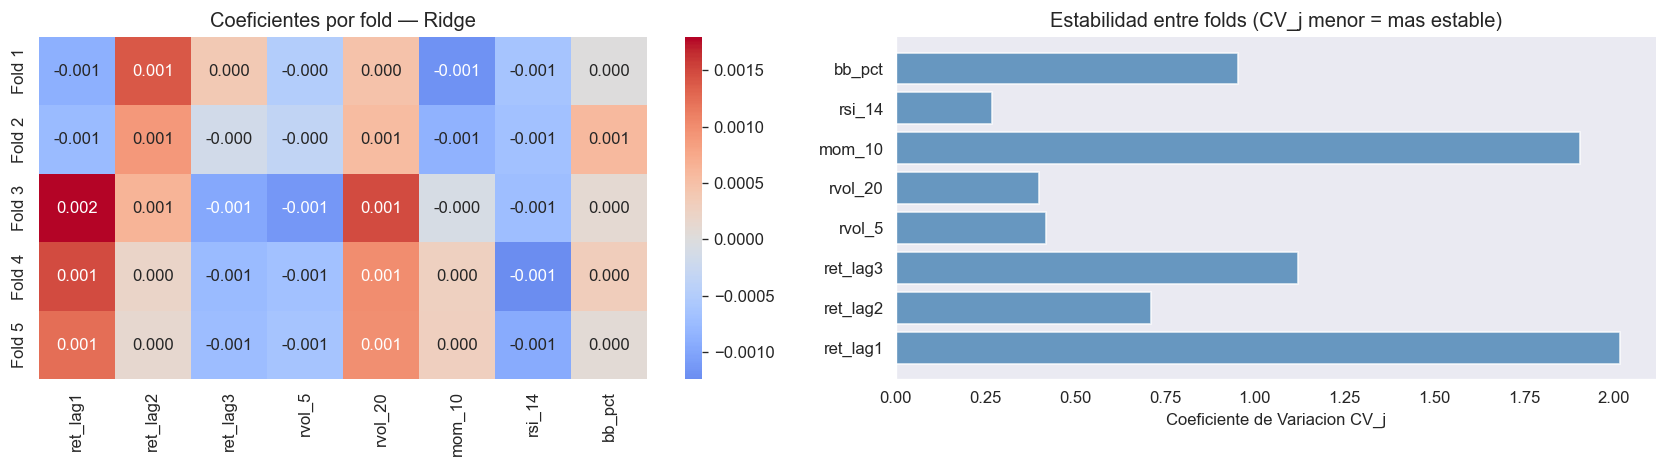

Top 3 features mas estables:
rsi_14     0.2681
rvol_20    0.4002
rvol_5     0.4194
dtype: float64

Top 3 features menos estables:
ret_lag1    2.0169
mom_10      1.9049
ret_lag3    1.1220
dtype: float64


In [24]:

best_name_q = 'Ridge'   # reemplaza con el ganador de 3.2 segun MAE OOT
tscv_coef   = TimeSeriesSplit(n_splits=5, gap=3)
feat_names_q = X_tr_q.columns.tolist()
coefs_by_fold = []

for tr, te in tscv_coef.split(X_tr_q):
    best_params = fitted_q[best_name_q].best_params_
    est_copy    = clone(specs_q[best_name_q][0])
    pipe_f      = Pipeline([('scaler', StandardScaler()), ('model', est_copy)])
    pipe_f.set_params(**best_params)
    pipe_f.fit(X_tr_q.iloc[tr], y_tr_q.iloc[tr])
    coefs_by_fold.append(pipe_f.named_steps['model'].coef_)

coefs_arr = np.array(coefs_by_fold)          # shape (K, p)
cv_j      = np.std(coefs_arr, axis=0) / np.maximum(np.abs(coefs_arr.mean(0)), 1e-8)

# genera los dos subgraficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Heatmap coeficientes (filas=folds, columnas=features)
sns.heatmap(coefs_arr, xticklabels=feat_names_q,
            yticklabels=[f'Fold {i+1}' for i in range(5)],
            cmap='coolwarm', center=0, ax=ax1, annot=True, fmt='.3f')
ax1.set_title(f'Coeficientes por fold — {best_name_q}')

# Barplot CV_j
ax2.barh(feat_names_q, cv_j, color='steelblue', alpha=0.8)
ax2.set_xlabel('Coeficiente de Variacion CV_j')
ax2.set_title('Estabilidad entre folds (CV_j menor = mas estable)')
plt.tight_layout(); plt.show()

# imprime top-3 features mas estables y top-3 menos estables
cv_series = pd.Series(cv_j, index=feat_names_q)

top3_estables = cv_series.sort_values().head(3)
top3_inestables = cv_series.sort_values(ascending=False).head(3)

print('Top 3 features mas estables:')
print(top3_estables.round(4))

print('\nTop 3 features menos estables:')
print(top3_inestables.round(4))

**Responde (mínimo 2 oraciones por pregunta):**

**a)** ¿Qué modelo seleccionarías para QQQ en producción y por qué? Justifica con al menos dos métricas de la tabla de 3.2.

> Para producción elegiría Ridge. Aunque Lasso y Elastic Net obtuvieron un MAE(OOT) ligeramente menor (0.009884 frente a 0.009909 de Ridge), ambos eliminaron todas las variables y produjeron un modelo sin capacidad interpretativa. Además, Ridge mantuvo las 8 features activas y obtuvo un RMSE(OOT) muy similar al mejor resultado, permitiendo capturar información de mercado sin perder estabilidad.

**b)** ¿Cuáles son las 3 features con mayor $CV_j$? ¿Qué implica esto sobre su utilidad como predictores de retornos de QQQ?

> oi Las tres features con mayor CVj fueron ret_lag1 (2.0169), mom_10 (1.9049) y ret_lag3 (1.1220). Esto indica que sus coeficientes cambian considerablemente entre folds, por lo que su señal predictiva no es consistente a lo largo del tiempo. En contraste, variables como rsi_14, rvol_20 y rvol_5 presentan coeficientes más estables, sugiriendo que podrían aportar información más robusta para predecir retornos de QQQ.

---
## Parte 4 — Forecast de Volatilidad HAR con Regularización *(25 pts)*

### Contexto

Usarás datos de **GLD** (ETF de Oro, 2018-2024) con un modelo tipo HAR regularizado. La volatilidad del oro es altamente persistente y predecible (contrario a sus retornos), lo que permite obtener $R^2 > 0$ en el set OOT. Además aplicarás el forecast en una estrategia de **inverse-vol position sizing**.

### Definición del target

Volatilidad realizada anualizada a $h = 5$ días:

$$\text{RV}_{t,5} = \sqrt{\sum_{i=1}^{5} r_{t+i}^2} \times \sqrt{252}$$

**Requisito de gap:** `TimeSeriesSplit(n_splits=5, gap=5)` — el gap debe ser $\geq h$ para evitar leakage del target.

### 4.1 — Feature Engineering HAR para GLD *(8 pts)*

Implementa `build_har_features_gld` con las 8 features del modelo HAR extendido:

| Feature | Construcción |
|---|---|
| `rvol_1d` | `\|r_{t-1}\| \times \sqrt{252}` |
| `rvol_5d` | `r.shift(1).rolling(5).std() * sqrt(252)` |
| `rvol_22d` | rolling 22 días con `shift(1)` |
| `rvol_60d` | rolling 60 días con `shift(1)` |
| `abs_ret` | `\|r_{t-1}\|` |
| `sq_ret` | `r_{t-1}^2` |
| `log_rvol22` | `log(rvol_{22d})` — usar `clip(lower=1e-6)` |
| `mom_5` | `prices.shift(1).pct_change(5)` |

**Verificación anti-leakage:** todas las features usan `shift(1)` o mayor; el target usa `shift(-h)`.

In [26]:
raw_gld    = yf.Ticker('GLD')
prices_gld = raw_gld.history(start='2018-01-01', end='2024-01-01')['Close']
prices_gld.index = prices_gld.index.tz_localize(None)
print(f'GLD: {len(prices_gld)} obs | {prices_gld.index[0].date()} — {prices_gld.index[-1].date()}')

h_gld = 5   # horizonte de prediccion en dias habiles

def build_har_features_gld(prices, h=5):
    """
    Features HAR extendidas para GLD. Sin leakage.
    Target: volatilidad realizada anualizada a h dias adelante.
    """
    r  = prices.pct_change()
    df = pd.DataFrame(index=prices.index)

    df['rvol_1d'] = r.shift(1).abs() * np.sqrt(252)

    df['rvol_5d'] = r.shift(1).rolling(5, min_periods=5).std() * np.sqrt(252)

    df['rvol_22d'] = r.shift(1).rolling(22, min_periods=22).std() * np.sqrt(252)

    df['rvol_60d'] = r.shift(1).rolling(60, min_periods=60).std() * np.sqrt(252)

    df['abs_ret'] = r.shift(1).abs()

    df['sq_ret'] = r.shift(1) ** 2

    df['log_rvol22'] = np.log(df['rvol_22d'].clip(lower=1e-6))

    df['mom_5'] = prices.shift(1).pct_change(5)

    rv_fwd = r.rolling(h).std().shift(-h) * np.sqrt(252)

    df['target'] = rv_fwd

    return df.dropna()


df_gld = build_har_features_gld(prices_gld, h=h_gld)
X_gld  = df_gld.drop(columns=['target'])
y_gld  = df_gld['target']

n_oot_g    = int(len(df_gld) * 0.2)
X_tr_g, y_tr_g = X_gld.iloc[:-n_oot_g], y_gld.iloc[:-n_oot_g]
X_ot_g, y_ot_g = X_gld.iloc[-n_oot_g:], y_gld.iloc[-n_oot_g:]
print(f'Train: {len(X_tr_g)} | OOT: {len(X_ot_g)}')
print(f'Target: media={y_gld.mean():.4f} | std={y_gld.std():.4f}')
print(f'Features: {X_gld.columns.tolist()}')

GLD: 1509 obs | 2018-01-02 — 2023-12-29
Train: 1155 | OOT: 288
Target: media=0.1265 | std=0.0670
Features: ['rvol_1d', 'rvol_5d', 'rvol_22d', 'rvol_60d', 'abs_ret', 'sq_ret', 'log_rvol22', 'mom_5']


### 4.2 — Comparación Ridge / Lasso / Elastic Net *(10 pts)*

Compara los tres modelos regularizados con `TimeSeriesSplit(n_splits=5, gap=5)`. Genera:

1. **Tabla OOT**: MAE, RMSE, R² para Ridge, Lasso, Elastic Net
2. **Gráfico serie temporal**: volatilidad realizada vs predicha del mejor modelo en el set OOT
3. **Scatter plot** predicho vs realizado con línea de 45° y R² anotado
4. **Gráfico de coeficientes** del mejor modelo (barh, colores por signo)

,MAE,RMSE,R2
Modelo,,,
Ridge,0.0457,0.0571,0.0757
Lasso,0.0465,0.0573,0.0686
ElasticNet,0.0463,0.0572,0.0736


Mejor modelo: Ridge


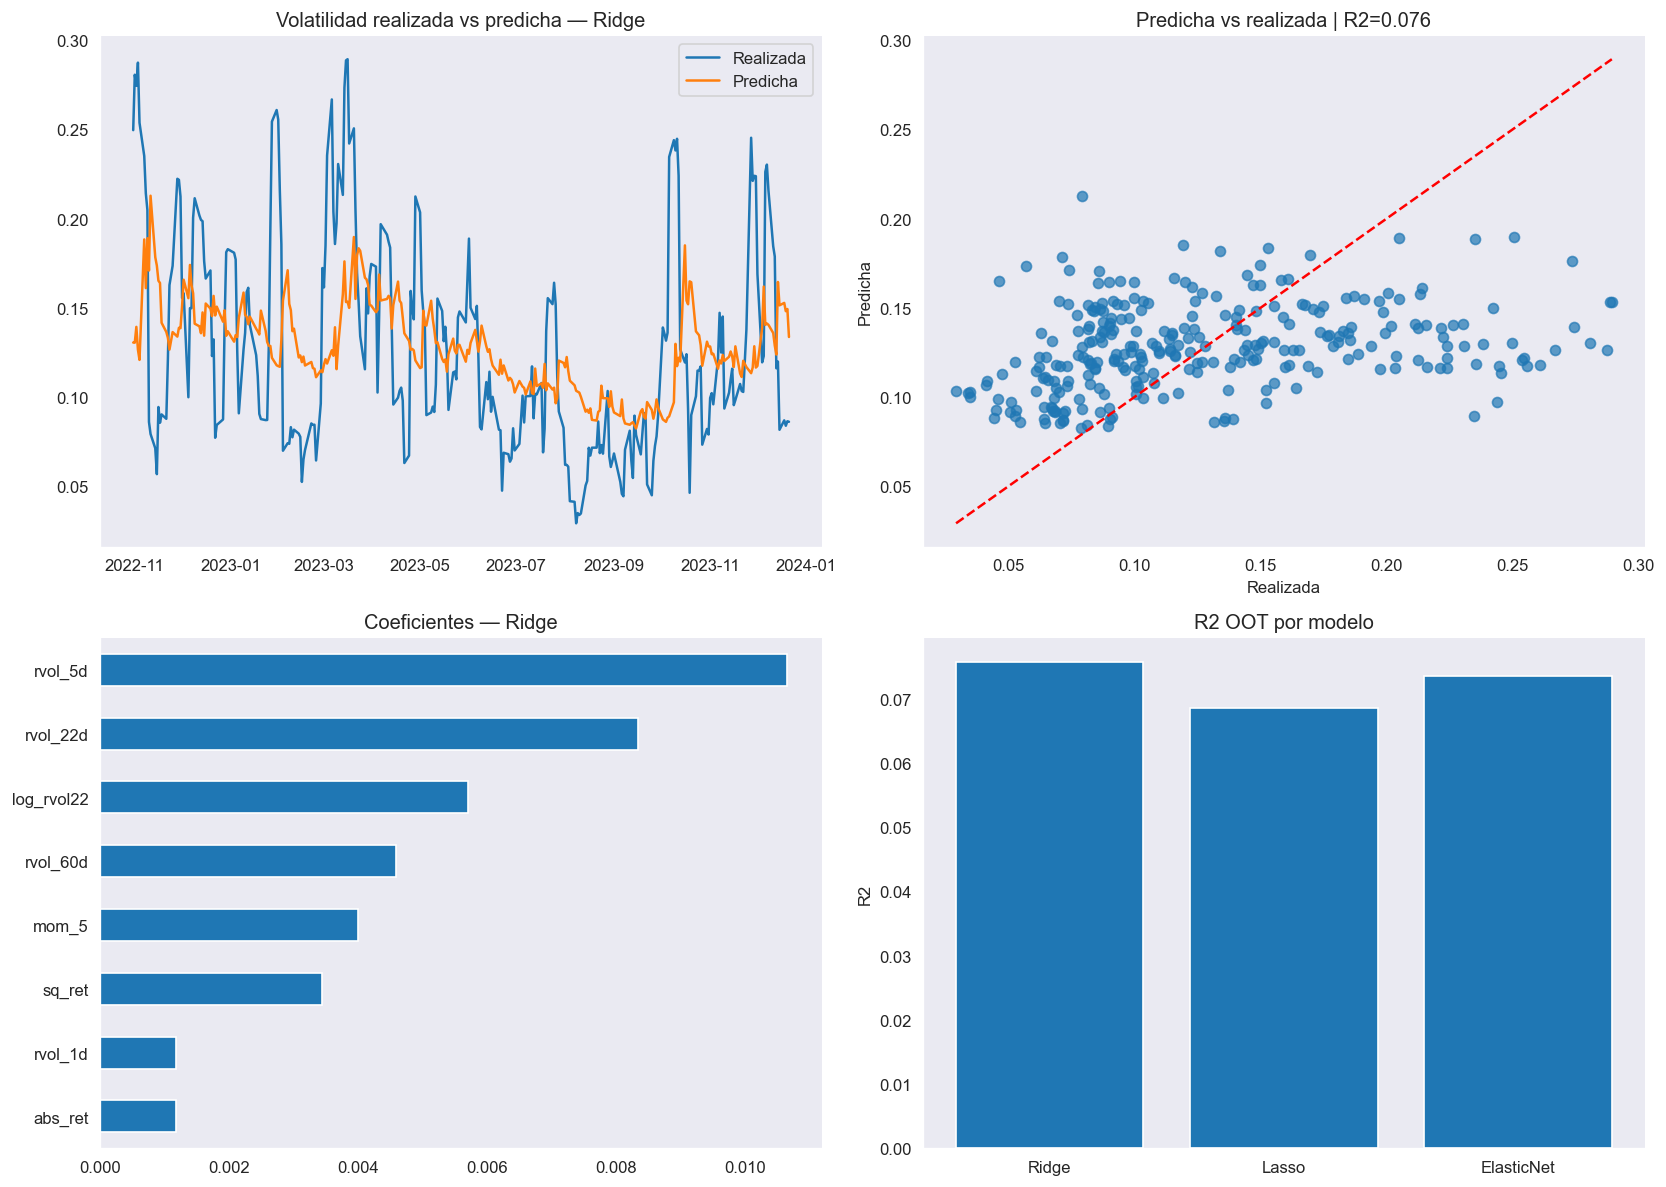

In [27]:

tscv_g = TimeSeriesSplit(n_splits=5, gap=h_gld)

specs_g = {
    'Ridge':      (Ridge(), {'model__alpha': np.logspace(-4, 2, 20)}),
    'Lasso':      (Lasso(max_iter=20000), {'model__alpha': np.logspace(-5, 0, 20)}),
    'ElasticNet': (ElasticNet(max_iter=20000), {
                  'model__alpha':    np.logspace(-5, 0, 10),
                  'model__l1_ratio': [0.1, 0.5, 0.9]}),
}

fitted_g = {}
oot_rows_g = []
for name, (est, params) in specs_g.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('model', est)])
    grid = GridSearchCV(pipe, params, scoring='neg_mean_absolute_error',
                        cv=tscv_g, n_jobs=-1, refit=True)
    grid.fit(X_tr_g, y_tr_g)
    fitted_g[name] = grid
    pred = grid.predict(X_ot_g)
    oot_rows_g.append({'Modelo': name,
                       'MAE':  mean_absolute_error(y_ot_g, pred),
                       'RMSE': np.sqrt(mean_squared_error(y_ot_g, pred)),
                       'R2':   r2_score(y_ot_g, pred)})

df_oot_g   = pd.DataFrame(oot_rows_g).set_index('Modelo')
best_gld   = df_oot_g['R2'].idxmax()
display(df_oot_g.round(4))
print(f'Mejor modelo: {best_gld}')

# genera los 4 graficos (fig, axes = plt.subplots(2, 2, figsize=(14, 10)))
pred_best_g = fitted_g[best_gld].predict(X_ot_g)
coef_best_g = fitted_g[best_gld].best_estimator_.named_steps['model'].coef_

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(y_ot_g.index, y_ot_g.values, label='Realizada')
axes[0, 0].plot(y_ot_g.index, pred_best_g, label='Predicha')
axes[0, 0].set_title(f'Volatilidad realizada vs predicha — {best_gld}')
axes[0, 0].legend()

axes[0, 1].scatter(y_ot_g, pred_best_g, alpha=0.7)
min_v = min(y_ot_g.min(), pred_best_g.min())
max_v = max(y_ot_g.max(), pred_best_g.max())
axes[0, 1].plot([min_v, max_v], [min_v, max_v], 'r--')
axes[0, 1].set_xlabel('Realizada')
axes[0, 1].set_ylabel('Predicha')
axes[0, 1].set_title(f'Predicha vs realizada | R2={r2_score(y_ot_g, pred_best_g):.3f}')

coef_series = pd.Series(coef_best_g, index=X_gld.columns)
coef_series.sort_values().plot(kind='barh', ax=axes[1, 0])
axes[1, 0].set_title(f'Coeficientes — {best_gld}')

axes[1, 1].bar(df_oot_g.index, df_oot_g['R2'])
axes[1, 1].set_title('R2 OOT por modelo')
axes[1, 1].set_ylabel('R2')

plt.tight_layout()
plt.show()

### 4.3 — Position Sizing con Volatilidad Predicha *(7 pts)*

Aplica el forecast de volatilidad a una estrategia de **inverse-vol position sizing**: mantener riesgo constante ajustando la exposición inversamente a la volatilidad predicha.

$$pos_t = \frac{\sigma_{\text{target}}}{\widehat{\text{RV}}_{t,5} / \sqrt{252}}, \qquad pos_t \in [0.1,\; 3.0]$$

donde $\sigma_{\text{target}} = 0.10/\sqrt{252}$ corresponde a 10% de volatilidad anual objetivo. El retorno diario de la estrategia es $r_t^{\text{strat}} = pos_{t-1} \cdot r_t^{\text{GLD}}$.

**Reporta:** retorno total, volatilidad anualizada y Sharpe ratio ($r_f = 0$) para la estrategia y para buy-and-hold de GLD en el período OOT.

=== Comparacion estrategia OOT ===
Buy-and-Hold GLD:
  Retorno total     : 23.68%
  Volatilidad anual : 14.09%
  Sharpe ratio      : 1.391
Inverse-Vol Strategy (Ridge):
  Retorno total     : 16.09%
  Volatilidad anual : 10.96%
  Sharpe ratio      : 1.251


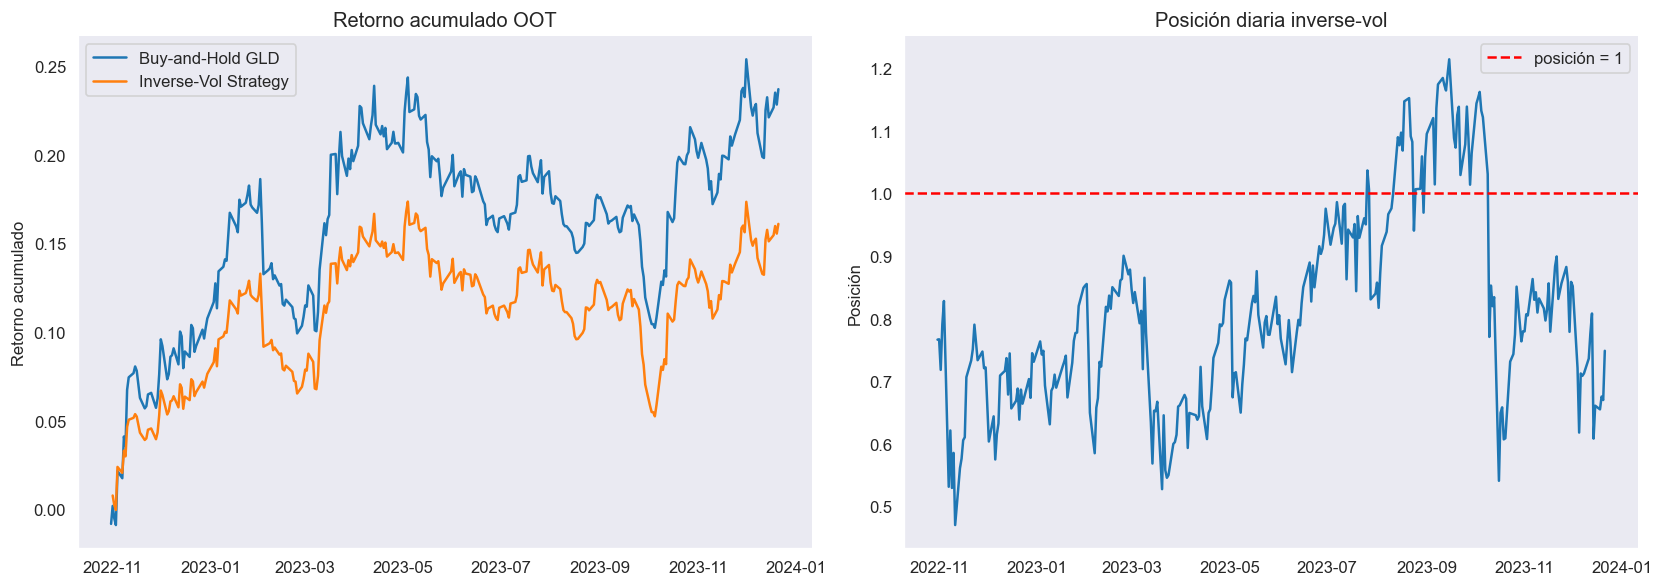

In [28]:

sigma_target = 0.10 / np.sqrt(252)       # vol diaria objetivo
rv_pred_oot  = fitted_g[best_gld].predict(X_ot_g)

# --- Position sizing ---
pos_t = sigma_target / np.maximum(rv_pred_oot / np.sqrt(252), 1e-6)
pos_t = np.clip(pos_t, 0.1, 3.0)

# --- Retornos ---
r_gld_oot = prices_gld.pct_change().reindex(y_ot_g.index)
r_strat   = pos_t[:-1] * r_gld_oot.values[1:]
r_bh      = r_gld_oot.dropna().values

def sharpe_ann(returns, freq=252):
    return np.sqrt(freq) * returns.mean() / (returns.std() + 1e-9)

print('=== Comparacion estrategia OOT ===')
print(f'Buy-and-Hold GLD:')
print(f'  Retorno total     : {(1 + r_bh).prod() - 1:.2%}')
print(f'  Volatilidad anual : {r_bh.std() * np.sqrt(252):.2%}')
print(f'  Sharpe ratio      : {sharpe_ann(r_bh):.3f}')
print(f'Inverse-Vol Strategy ({best_gld}):')
print(f'  Retorno total     : {(1 + r_strat).prod() - 1:.2%}')
print(f'  Volatilidad anual : {r_strat.std() * np.sqrt(252):.2%}')
print(f'  Sharpe ratio      : {sharpe_ann(r_strat):.3f}')

# genera dos subgraficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Retorno acumulado
cum_bh = (1 + r_bh).cumprod() - 1
cum_strat = (1 + r_strat).cumprod() - 1

ax1.plot(y_ot_g.index[-len(cum_bh):], cum_bh, label='Buy-and-Hold GLD')
ax1.plot(y_ot_g.index[-len(cum_strat):], cum_strat, label='Inverse-Vol Strategy')

ax1.set_title('Retorno acumulado OOT')
ax1.set_ylabel('Retorno acumulado')
ax1.legend()

# Posición diaria
ax2.plot(y_ot_g.index[:len(pos_t)], pos_t)
ax2.axhline(1.0, color='red', linestyle='--', label='posición = 1')

ax2.set_title('Posición diaria inverse-vol')
ax2.set_ylabel('Posición')
ax2.legend()

plt.tight_layout()
plt.show()

**Responde (mínimo 2 oraciones por pregunta):**

**a)** ¿Qué modelo (Ridge, Lasso, Elastic Net) logró el mayor $R^2$ en GLD OOT? ¿Qué features HAR tienen los coeficientes más grandes?

> El modelo Ridge obtuvo el mayor $R^2$ en el conjunto OOT, alcanzando un valor de 0.0757, superior a Lasso y Elastic Net. Esto indica que Ridge capturó mejor la persistencia de la volatilidad futura de GLD. Las features con coeficientes más grandes fueron rvol_5d, rvol_22d, log_rvol22 y rvol_60d. Esto es consistente con la literatura HAR, donde la volatilidad pasada en distintos horizontes temporales es el principal predictor de la volatilidad futura.

**b)** Compara el $R^2$ del forecast de volatilidad de GLD con el Spearman $\rho$ de la predicción de retornos de QQQ (Parte 3). ¿Qué dice esto sobre la predictibilidad relativa de volatilidad vs retornos?

> El $R^2$ de la predicción de volatilidad para GLD fue positivo (0.0757), mientras que en la Parte 3 las predicciones de retornos de QQQ mostraron valores de Spearman cercanos a cero. Esto sugiere que la volatilidad es significativamente más predecible que los retornos financieros. En los mercados financieros es común observar persistencia en la volatilidad, mientras que los retornos diarios suelen comportarse de manera mucho más cercana a un proceso aleatorio. Por ello, los modelos de volatilidad suelen obtener métricas predictivas superiores a las de modelos de retornos.

**c)** ¿La estrategia inverse-vol mejoró el Sharpe ratio respecto a buy-and-hold de GLD? ¿En qué períodos la posición fue mayor a 1 (apalancamiento) y es esto razonable desde la gestión de riesgo?

> La estrategia inverse-vol redujo la volatilidad anual desde 14.09% hasta 10.96%, pero también redujo el retorno total desde 23.68% hasta 16.09%. Como consecuencia, el Sharpe ratio disminuyó de 1.391 a 1.251, por lo que la estrategia no logró mejorar el desempeño ajustado por riesgo en el período OOT. La posición fue superior a 1 principalmente entre agosto y octubre de 2023, cuando el modelo predecía niveles relativamente bajos de volatilidad futura. Desde una perspectiva de gestión de riesgo esto es razonable, ya que la estrategia aumenta la exposición cuando el riesgo esperado es menor y la reduce cuando la volatilidad prevista aumenta.

**d)** Si el forecast de volatilidad tuviera error cero, ¿dominaría siempre la estrategia inverse-vol al buy-and-hold en Sharpe ratio? Argumenta usando la fórmula $\text{Sharpe} = \sqrt{252} \cdot \mu / \sigma$.

> Incluso con un forecast de volatilidad perfecto, la estrategia inverse-vol no necesariamente dominaría al buy-and-hold en términos de Sharpe ratio. La razón es que controlar la volatilidad no garantiza aumentar el retorno esperado del activo. Según la fórmula $\text{Sharpe} = \sqrt{252} \cdot \mu / \sigma$, una reducción de la volatilidad (σ) mejora el Sharpe solamente si el retorno promedio (μ) no disminuye proporcionalmente. Si la reducción de exposición ocurre durante períodos de altos retornos, el Sharpe puede incluso empeorar, como ocurrió en este ejercicio.

---
## Parte 5 — SNR Empírico y Análisis por Régimen *(Bonus — 15 pts)*

### Contexto

En clase vimos que el SNR extremadamente bajo de los retornos financieros es la razón fundamental para regularizar. En esta parte estimarás el SNR empíricamente y analizarás si la regularización estabiliza el modelo de QQQ en regímenes de alta y baja volatilidad.

### 5.1 — Estimación del SNR *(5 pts)*

Para NVDA y QQQ, estima el SNR empírico:

$$\text{SNR} = \left(\frac{\hat{\mu}_d}{\hat{\sigma}_d}\right)^2$$

y el gap teórico entre riesgo empírico y verdadero:

$$\text{Gap} \approx \frac{p}{T \cdot \text{SNR}}$$

Donde $p$ es el número de features del modelo. Genera un gráfico que muestre cómo el Gap varía con el SNR para distintos valores de $p$, e indica dónde caen NVDA y QQQ.

In [14]:
# TODO: calcula SNR para NVDA y QQQ
# r_nvda_s = prices_nvda.pct_change().dropna()
# r_qqq_s  = prices_qqq.pct_change().dropna()

# activos = [
#     ('NVDA', r_nvda_s, X_ext.shape[1]),
#     ('QQQ',  r_qqq_s,  8),              # 8 features del modelo 3.1
# ]
# snr_dict = {}
# for name, r_s, p in activos:
#     mu_d  = r_s.mean()
#     sig_d = r_s.std()
#     snr   = (mu_d / sig_d) ** 2
#     T     = len(r_s)
#     gap   = p / (T * max(snr, 1e-10))
#     snr_dict[name] = snr
#     print(f'{name}: mu={mu_d:.5f} | sigma={sig_d:.4f} | SNR={snr:.5f} | T={T} | p={p} | Gap={gap:.1f}')

# TODO: grafico Gap vs SNR para distintos p
# fig, ax = plt.subplots(figsize=(9, 5))
# snr_range = np.logspace(-5, 0, 200)
# T_ref = 1500
# for p_val, color in [(5, 'blue'), (10, 'green'), (20, 'orange')]:
#     ax.loglog(snr_range, p_val / (T_ref * snr_range), lw=2, color=color, label=f'p={p_val}')
# for name, snr_val in snr_dict.items():
#     ax.axvline(snr_val, ls='--', label=f'SNR {name}={snr_val:.5f}')
# ax.set_xlabel('SNR'); ax.set_ylabel('Gap = p / (T * SNR)')
# ax.set_title('Gap entre riesgo empirico y verdadero')
# ax.legend(); plt.tight_layout(); plt.show()
pass

### 5.2 — Performance por Régimen de Volatilidad *(10 pts)*

Define dos regímenes para QQQ en el set OOT según `rvol_20`:

- **Régimen Tranquilo (LV):** `rvol_20 ≤ percentil_75`
- **Régimen Volátil (HV):** `rvol_20 > percentil_75`

Calcula MAE por régimen para cada modelo (OLS, Ridge, Lasso, ElasticNet). Genera un heatmap con los resultados y responde las preguntas.

In [15]:
# Descomenta cuando hayas completado la Parte 3

# rvol20_oot = X_ot_q['rvol_20'] if 'rvol_20' in X_ot_q.columns else None
# if rvol20_oot is not None:
#     p75    = rvol20_oot.quantile(0.75)
#     mask_hv = rvol20_oot > p75
#     mask_lv = ~mask_hv
#     print(f'OOT: {mask_hv.sum()} dias HV ({mask_hv.mean():.1%}) | {mask_lv.sum()} dias LV')

#     regime_rows = []
#     for name, grid in fitted_q.items():
#         pred = grid.predict(X_ot_q)
#         regime_rows.append({
#             'Modelo':      name,
#             'MAE_LV':     mean_absolute_error(y_ot_q[mask_lv], pred[mask_lv]),
#             'MAE_HV':     mean_absolute_error(y_ot_q[mask_hv], pred[mask_hv]),
#         })
#     df_reg = pd.DataFrame(regime_rows).set_index('Modelo')
#     df_reg['Ratio_HV/LV'] = df_reg['MAE_HV'] / df_reg['MAE_LV']
#     display(df_reg.round(6))

#     # TODO: heatmap comparativo
#     # fig, ax = plt.subplots(figsize=(8, 4))
#     # sns.heatmap(df_reg[['MAE_LV', 'MAE_HV']], annot=True, fmt='.6f',
#     #             cmap='YlOrRd', ax=ax, linewidths=0.5)
#     # ax.set_title('MAE por regimen de volatilidad — QQQ OOT')
#     # plt.tight_layout(); plt.show()
pass

**Responde (mínimo 2 oraciones por pregunta):**

**a)** Con los SNR calculados en 5.1, ¿cuál activo (NVDA o QQQ) requiere más regularización y por qué? ¿Cómo se relaciona el SNR con el $\lambda^*$ óptimo que encontraste en la Parte 3?

> *Completa aquí*

**b)** ¿Qué modelo muestra el menor ratio $\text{MAE}_{HV}/\text{MAE}_{LV}$ en QQQ (es decir, el más estable entre regímenes)? ¿Tiene sentido que la regularización ayude especialmente en períodos de alta volatilidad?

> *Completa aquí*

**c)** Si diseñaras un modelo en producción para QQQ, ¿preferirías un modelo único entrenado en todos los regímenes o dos modelos separados? Argumenta con los resultados del heatmap.

> *Completa aquí*

---
## Tabla de Puntajes

| Parte | Descripción | Pts |
|---|---|---|
| 1.1 | `ridge_closed_form` + verificación vs sklearn + Ridge path (2 paneles) | 10 |
| 1.2 | Dataset multicolineal + heatmap correlación + CV MAE vs λ + λ* + cond. number | 15 |
| 2.1 | `soft_threshold` (test OK) + `lasso_coordinate_descent` (diff < 1e-4) + curvas de convergencia | 12 |
| 2.2 | Lasso path (2 paneles) + identificación 5 primeras features | 8 |
| 2.3 | Interpretación Ridge vs Lasso (3 preguntas) | 5 |
| 3.1 | `build_features_qqq` (≥8 features, incluye `rsi_14` y `bb_pct`) | 8 |
| 3.2 | Pipeline OLS/Ridge/Lasso/EN + tabla completa OOT | 12 |
| 3.3 | Heatmap coeficientes + barplot $CV_j$ + 2 preguntas | 5 |
| 4.1 | `build_har_features_gld` (8 features HAR, gap correcto) | 8 |
| 4.2 | Comparación Ridge/Lasso/EN + tabla OOT + 4 gráficos | 10 |
| 4.3 | Inverse-vol position sizing + comparación Sharpe + 4 preguntas | 7 |
| **Total obligatorio** | | **100** |
| Bonus 5.1 | SNR empírico NVDA/QQQ + gráfico Gap vs SNR | 5 |
| Bonus 5.2 | Heatmap MAE por régimen HV/LV + 3 preguntas | 10 |